In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
class CandlestickIndicators:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

        # price series
        self.open = self.df['Open']
        self.close = self.df['Close']
        self.high = self.df['High']
        self.low = self.df['Low']

        # candle components
        self.body = (self.close - self.open).abs()

        self.upper_shadow = (
            self.high - pd.concat([self.open, self.close], axis=1).max(axis=1)
        )

        self.lower_shadow = (
            pd.concat([self.open, self.close], axis=1).min(axis=1) - self.low
        )

        # direction
        self.is_bull = self.close > self.open
        self.is_bear = self.close < self.open

        # RSI & MACD
        self.rsi = self.compute_rsi()
        self.macd, self.macd_signal, self.macd_hist = self.compute_macd()
        
    # trend
    def downtrend(self, n=5):
        return self.close < self.close.rolling(n).mean()
        
    def uptrend(self, n=5):
        return self.close > self.close.rolling(n).mean()

    # RSI
    def compute_rsi(self, period=14):

        delta = self.close.diff()

        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))

        return rsi

    # MACD
    def compute_macd(self, fast=12, slow=26, signal=9):

        ema_fast = self.close.ewm(span=fast, adjust=False).mean()
        ema_slow = self.close.ewm(span=slow, adjust=False).mean()

        macd = ema_fast - ema_slow
        macd_signal = macd.ewm(span=signal, adjust=False).mean()
        macd_hist = macd - macd_signal

        return macd, macd_signal, macd_hist

In [8]:
class CandlestickPatterns(CandlestickIndicators):

    # -------- single candle --------
    def hammer(self, trend_n=5):
        return (
            (self.lower_shadow >= 2 * self.body) &
            (self.upper_shadow <= 0.3 * self.body) &
            self.downtrend(trend_n)
        ).fillna(0).astype(int)


    def hanging_man(self, trend_n=5):
        shape = (
            (self.lower_shadow >= 2 * self.body) &
            (self.upper_shadow <= 0.3 * self.body) &
            self.uptrend(trend_n)
        )
        
        return (shape).fillna(0).astype(int)* -1

        
    def shooting_star(self, trend_n=5):
        shape = (
            (self.upper_shadow >= 2 * self.body) &
            (self.lower_shadow <= 0.3 * self.body)
        )
    
        return (
            shape &
            self.uptrend(trend_n)
        ).fillna(0).astype(int)* -1


    def inverted_hammer(self, trend_n=5):
    
        shape = (
            (self.upper_shadow >= 2 * self.body) &
            (self.lower_shadow <= 0.3 * self.body)
        )
    
        pattern = (
            shape &
            self.downtrend(trend_n)
        )
    
    
        return (pattern).fillna(0).astype(int)


    # -------- two candle --------
    def bearish_engulfing(self, trend_n=5):
        pattern = (
            self.uptrend(trend_n).shift(1) &
            self.is_bear &
            self.is_bull.shift(1) &
            (self.open >= self.close.shift(1)) &
            (self.close <= self.open.shift(1))
        )
    
        confirmation = (
            self.close.shift(-1) <
            pd.concat([self.open, self.close], axis=1).min(axis=1)
        )
    
        return (pattern & confirmation).shift(1).fillna(0).astype(int)* -1


    def bullish_engulfing(self, trend_n=5):
        shape = (
            self.downtrend(trend_n).shift(1) &
            self.is_bull &
            self.is_bear.shift(1) &
            (self.open <= self.close.shift(1)) &
            (self.close >= self.open.shift(1))
        )
         
        confirmation = (
            self.close.shift(-1) >
            pd.concat([self.open, self.close], axis=1).max(axis=1)
        )

        return (shape & confirmation).shift(1).fillna(0).astype(int)



    def piercing_pattern(self):
        prev_mid = (self.open.shift(1) + self.close.shift(1)) / 2
        return (
            self.is_bull &
            self.is_bear.shift(1) &
            (self.open < self.low.shift(1)) &
            (self.close > prev_mid)
        ).fillna(0).astype(int)

    def dark_cloud_cover(self):
        prev_mid = (self.open.shift(1) + self.close.shift(1)) / 2
        return (
            self.is_bear &
            self.is_bull.shift(1) &
            (self.open > self.high.shift(1)) &
            (self.close < prev_mid)
        ).fillna(0).astype(int)* -1

    # -------- three candle --------
    def morning_star(self, trend_n=5):
        pattern = (
            self.downtrend(trend_n).shift(2) &                     
            self.is_bear.shift(2) &                       
            (self.body.shift(1) < 0.5 * self.body.shift(2)) &  
            self.is_bull &                               
            (self.close > (self.open.shift(2) + self.close.shift(2)) / 2)
        )
    
        confirmation = (
            self.close.shift(-1) >
            pd.concat([self.open, self.close], axis=1).max(axis=1)
        )
   
    
        return (pattern & confirmation).shift(1).fillna(0).astype(int)


    def evening_star(self, trend_n=5):

        pattern = (
            self.uptrend(trend_n).shift(2) &                     
            self.is_bull.shift(2) &                       
            (self.body.shift(1) < 0.5 * self.body.shift(2)) &  
            self.is_bear &                               
            (self.close < (self.open.shift(2) + self.close.shift(2)) / 2)
        )
    
        confirmation = (
            self.close.shift(-1) <
            pd.concat([self.open, self.close], axis=1).min(axis=1)
        )
  
        return (pattern & confirmation).shift(1).fillna(0).astype(int)* -1
        

    # -------- continuous pattern --------
    def rising_three_methods(
        self,
        n_small=3,
        body_multiplier=1.2,
        inside_tol=0.01,
        strong_close_ratio=0,
        trend_n=5
    ):
    
        total_window = n_small + 2 
        first_idx = total_window - 1
    
        avg_body = self.body.rolling(20).mean()
    
        first_long_bull = (
            self.is_bull.shift(first_idx) &
            (self.body.shift(first_idx) >
             body_multiplier * avg_body.shift(first_idx))
        )
    
        inside_range = True
        for i in range(1, n_small + 1):
    
            inside_range &= (
                (self.high.shift(first_idx - i) <=
                 self.high.shift(first_idx) * (1 + inside_tol)) &
                (self.low.shift(first_idx - i) >=
                 self.low.shift(first_idx) * (1 - inside_tol))
            )
    
        final_strong_bull = (
            self.is_bull &
            (
                self.close >
                self.close.shift(first_idx) +
                strong_close_ratio * self.body.shift(first_idx)
            )
        )
    
        trend_filter = self.uptrend(trend_n).shift(first_idx)
    
        pattern = (
            trend_filter &
            first_long_bull &
            inside_range &
            final_strong_bull
        )
    
        return pattern.astype(int)


    def falling_three_methods(
        self,
        n_small=3,
        body_multiplier=1.2,
        inside_tol=0.01,
        strong_close_ratio=0,
        trend_n=5
    ):

        first_long_black = (
            self.is_bear.shift(n_small + 1) &
            (self.body.shift(n_small + 1) >
             body_multiplier * self.body.rolling(20).mean().shift(n_small + 1))
        )
    
        inside_range = True
        for i in range(1, n_small + 1):
            inside_range &= (
                self.high.shift(i) <=
                self.high.shift(n_small + 1) * (1 + inside_tol)
            ) & (
                self.low.shift(i) >=
                self.low.shift(n_small + 1) * (1 - inside_tol)
            )
    
        final_strong_black = (
            self.is_bear &
            (
                self.close <
                self.close.shift(n_small + 1)
                - strong_close_ratio * self.body.shift(n_small + 1)
            )
        )
    
        pattern = (
            self.downtrend(trend_n).shift(n_small + 1) &
            first_long_black &
            inside_range &
            final_strong_black
        )
    
        return pattern.astype(int)* -1

    # RSI signals
    def rsi_oversold(self, threshold=30):
        return (self.rsi < threshold).astype(int)

    def rsi_overbought(self, threshold=70):
        return (self.rsi > threshold).astype(int)* -1

    def rsi_bearish_divergence(self, lookback=20):
    
        price_new_high = self.close == self.close.rolling(lookback).max()
        rsi_not_new_high = self.rsi < self.rsi.rolling(lookback).max()
    
        return (price_new_high & rsi_not_new_high).astype(int)* -1

    def rsi_bullish_divergence(self, lookback=20):

        price_new_low = self.close == self.close.rolling(lookback).min()
        rsi_not_new_low = self.rsi > self.rsi.rolling(lookback).min()
    
        return (price_new_low & rsi_not_new_low).astype(int)

    # MACD signals
    def macd_bullish_cross(self):
        return (
            (self.macd > self.macd_signal) &
            (self.macd.shift(1) <= self.macd_signal.shift(1))
        ).astype(int)

    def macd_bearish_cross(self):
        return (
            (self.macd < self.macd_signal) &
            (self.macd.shift(1) >= self.macd_signal.shift(1))
        ).astype(int)* -1



In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("C:/Users/tian/Desktop/mint/spx_d.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()
df.head()

,Date,Open,High,Low,Close,Volume
0,2000-01-03,1469.25,1478.00,1438.36,1455.22,517666667.0
1,2000-01-04,1455.22,1455.22,1397.43,1399.42,560555556.0
2,2000-01-05,1399.42,1413.27,1377.68,1402.11,603055556.0
3,2000-01-06,1402.11,1411.90,1392.10,1403.45,606833333.0
4,2000-01-07,1403.45,1441.47,1400.73,1441.47,680666667.0


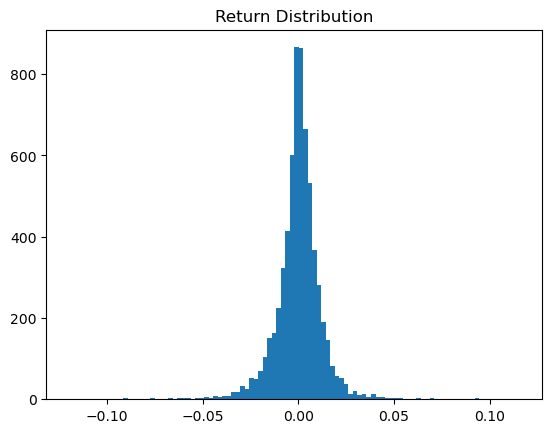

In [12]:
price = df["Close"]
ret = price.pct_change().dropna()
plt.hist(ret, bins=100)
plt.title("Return Distribution")
plt.show()

In [17]:
patterns = CandlestickPatterns(df)

indicator_funcs = {
    "hammer": patterns.hammer,
    "hanging_man": patterns.hanging_man,
    "inverted_hammer": patterns.inverted_hammer,
    "shooting_star": patterns.shooting_star,

    "bullish_engulfing": patterns.bullish_engulfing,
    "bearish_engulfing": patterns.bearish_engulfing,
    "piercing_pattern": patterns.piercing_pattern,
    "dark_cloud_cover": patterns.dark_cloud_cover,

    "morning_star": patterns.morning_star,
    "evening_star": patterns.evening_star,
    
    "rising_three_methods": patterns.rising_three_methods,
    "falling_three_methods": patterns.falling_three_methods,

    "rsi_oversold": patterns.rsi_oversold,
    "rsi_overbought": patterns.rsi_overbought,
    "rsi_bearish_divergence": patterns.rsi_bearish_divergence,
    "rsi_bullish_divergence": patterns.rsi_bullish_divergence,

    "macd_bullish_cross": patterns.macd_bullish_cross,
    "macd_bearish_cross": patterns.macd_bearish_cross

    
}

for name, func in indicator_funcs.items():
    df[name] = func()


In [18]:
df.head(10)

,Date,Open,High,Low,Close,Volume,hammer,hanging_man,inverted_hammer,shooting_star,...,morning_star,evening_star,rising_three_methods,falling_three_methods,rsi_oversold,rsi_overbought,rsi_bearish_divergence,rsi_bullish_divergence,macd_bullish_cross,macd_bearish_cross
0,2000-01-03,1469.25,1478.00,1438.36,1455.22,517666667.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2000-01-04,1455.22,1455.22,1397.43,1399.42,560555556.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,-1
2,2000-01-05,1399.42,1413.27,1377.68,1402.11,603055556.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,2000-01-06,1402.11,1411.90,1392.10,1403.45,606833333.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2000-01-07,1403.45,1441.47,1400.73,1441.47,680666667.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5,2000-01-10,1441.47,1464.36,1441.47,1457.60,591555556.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6,2000-01-11,1457.60,1458.66,1434.42,1438.56,563333333.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
7,2000-01-12,1438.56,1442.60,1427.08,1432.25,541444444.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,2000-01-13,1432.25,1454.20,1432.25,1449.68,572444444.0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
9,2000-01-14,1449.68,1473.00,1449.68,1465.15,603277778.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [20]:
def jaccard_similarity(s1, s2):

    A = s1 != 0
    B = s2 != 0
    
    union = (A | B).sum()
    
    if union == 0:
        return np.nan
    
    intersection = (A & B).sum()
    
    return intersection / union

indicator_names = list(indicator_funcs.keys())

jaccard_matrix = pd.DataFrame(
    index=indicator_names,
    columns=indicator_names
)

for i in indicator_names:
    for j in indicator_names:
        
        s1 = df[i]
        s2 = df[j]
        
        jaccard_matrix.loc[i, j] = jaccard_similarity(s1, s2)

jaccard_matrix = jaccard_matrix.astype(float)
jaccard_matrix.to_csv("indicator_jaccard_matrix.csv")
print("Jaccard similarity matrix saved.")

Jaccard similarity matrix saved.


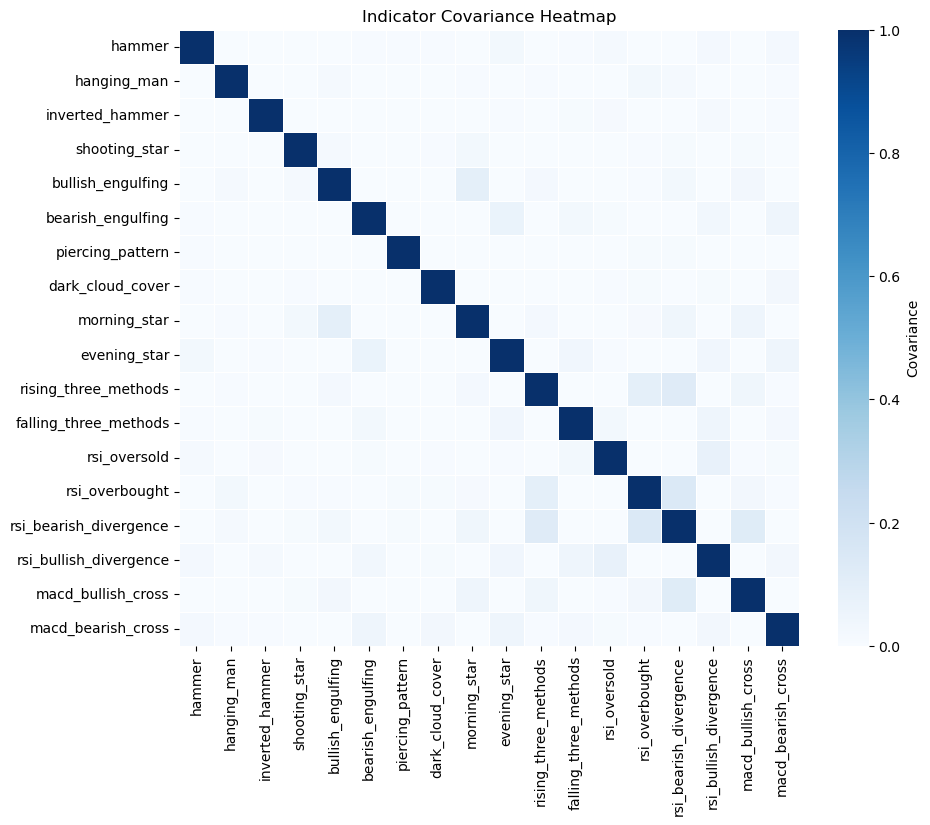

In [23]:
import seaborn as sns
df_cov = pd.read_csv(r"C:\Users\tian\Desktop\mint\indicators\indicator_jaccard_matrix.csv", index_col=0)

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_cov, 
    annot=False,           
    fmt=".4f",           
    cmap='Blues',       
    linewidths=0.5,     
    cbar_kws={"label": "Covariance"} 
)

plt.title("Indicator Covariance Heatmap")
plt.show()

In [25]:
jaccard_distance = 1 - jaccard_matrix

jaccard_distance = jaccard_distance.astype(float)

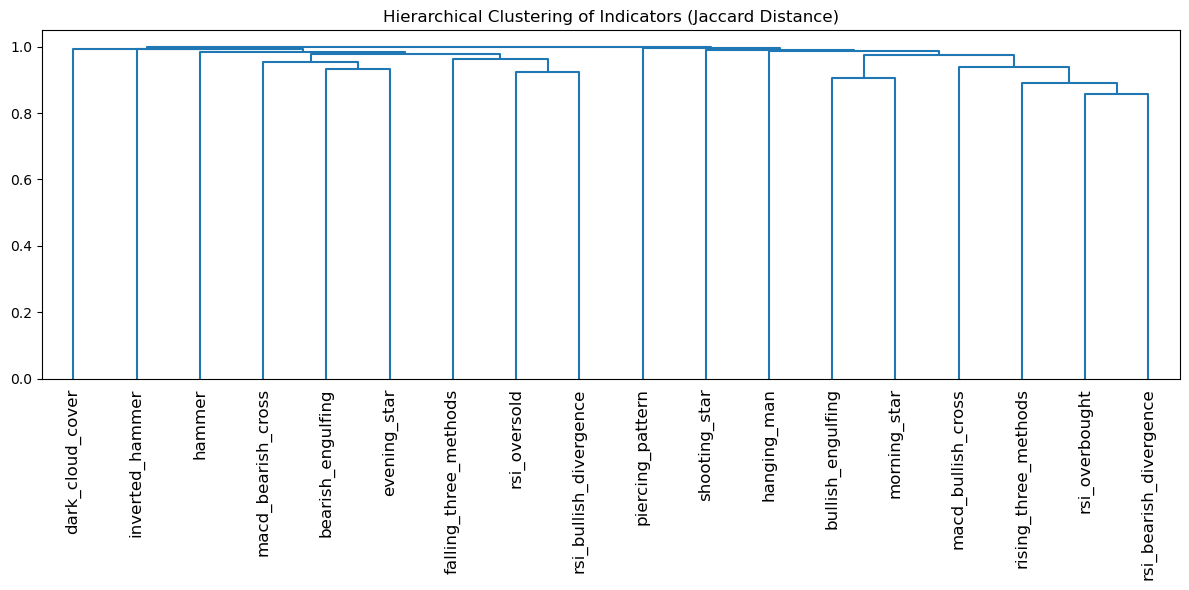

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

condensed_dist = squareform(jaccard_distance.values)

Z = linkage(condensed_dist, method='average')

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    labels=jaccard_distance.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Indicators (Jaccard Distance)")
plt.tight_layout()
plt.show()

In [27]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=4, criterion='maxclust')

cluster_df = pd.DataFrame({
    "Indicator": jaccard_distance.index,
    "Cluster": clusters
})

print(cluster_df.sort_values("Cluster"))

                 Indicator  Cluster
0                   hammer        1
15  rsi_bullish_divergence        1
12            rsi_oversold        1
11   falling_three_methods        1
9             evening_star        1
17      macd_bearish_cross        1
2          inverted_hammer        1
5        bearish_engulfing        1
7         dark_cloud_cover        2
16      macd_bullish_cross        3
4        bullish_engulfing        3
10    rising_three_methods        3
3            shooting_star        3
13          rsi_overbought        3
14  rsi_bearish_divergence        3
1              hanging_man        3
8             morning_star        3
6         piercing_pattern        4


In [28]:
all_sums = df.sum(numeric_only=True)
print(all_sums)

Open                      1.500072e+07
High                      1.508588e+07
Low                       1.490874e+07
Close                     1.500283e+07
Volume                    1.264564e+13
hammer                    8.200000e+01
hanging_man              -9.700000e+01
inverted_hammer           4.600000e+01
shooting_star            -5.900000e+01
bullish_engulfing         1.270000e+02
bearish_engulfing        -1.230000e+02
piercing_pattern          5.700000e+01
dark_cloud_cover         -7.700000e+01
morning_star              1.380000e+02
evening_star             -1.190000e+02
rising_three_methods      2.190000e+02
falling_three_methods    -7.900000e+01
rsi_oversold              1.580000e+02
rsi_overbought           -4.020000e+02
rsi_bearish_divergence   -5.740000e+02
rsi_bullish_divergence    1.750000e+02
macd_bullish_cross        2.800000e+02
macd_bearish_cross       -2.810000e+02
dtype: float64


In [29]:
def evaluate_signal(signal, price, horizon=1):

    future_ret = price.pct_change(horizon).shift(-horizon)
    mask = signal != 0

    aligned_signal = signal[mask]
    aligned_ret = future_ret[mask]

    N = len(aligned_ret)

    if N == 0:
        return {
            "N": 0,
            "Directional Accuracy": np.nan,
            "Mean Return": np.nan,
            "Sharpe": np.nan,
            "t-stat": np.nan
        }

    strategy_ret = aligned_signal * aligned_ret

    directional = (strategy_ret > 0).mean()
    mean_ret = strategy_ret.mean()
    std_ret = strategy_ret.std()

    sharpe = mean_ret / std_ret if std_ret != 0 else np.nan

    t_stat = mean_ret / (std_ret / np.sqrt(N)) if std_ret != 0 else np.nan

    return {
        "N": N,
        "Directional Accuracy": directional,
        "Mean Return": mean_ret,
        "Sharpe": sharpe,
        "t-stat": t_stat
    }


In [30]:
results = {}

for name, func in indicator_funcs.items():

    signal = func()

    perf = evaluate_signal(
        signal=signal,
        price=df["Close"],
        horizon=5
    )

    results[name] = perf



In [33]:
horizon = 5   

all_time_series = []

for name, func in indicator_funcs.items():

    signal_raw = func()   # 1 / -1 / 0


    daily_ret = df["Close"].pct_change()

    position = signal_raw.replace(0, np.nan)  
    

    position = position.ffill(limit=horizon-1) 
    
    position = position.fillna(0)

    strategy_ret = position.shift(1) * daily_ret

    temp = pd.DataFrame({
        "Date": df["Date"],
        "Indicator": name,
        "Return": strategy_ret
    })

    all_time_series.append(temp)

time_series_df = pd.concat(all_time_series)
time_series_df = time_series_df.dropna()

time_series_df["Cumulative Return"] = (
    time_series_df
        .groupby("Indicator")["Return"]
        .transform(lambda x: (1 + x).cumprod() - 1)
)

time_series_df.to_csv("momentum_time_series.csv", index=False)

print("Time series table saved.")

Time series table saved.


In [40]:
print(time_series_df.groupby("Indicator")["Return"].sum())

Indicator
bearish_engulfing        -0.089638
bullish_engulfing        -0.351335
dark_cloud_cover         -0.536735
evening_star             -0.549782
falling_three_methods    -0.350226
hammer                   -0.155735
hanging_man              -0.168439
inverted_hammer           0.372033
macd_bearish_cross       -0.887837
macd_bullish_cross        0.462536
morning_star              0.068368
piercing_pattern          0.055639
rising_three_methods     -0.021543
rsi_bearish_divergence    0.186358
rsi_bullish_divergence    0.538368
rsi_overbought           -0.081934
rsi_oversold              0.264748
shooting_star            -0.308005
Name: Return, dtype: float64


In [41]:
def newey_west_tstat(x, lag):
    x = np.array(x)
    N = len(x)
    mean_x = np.mean(x)
    x_demean = x - mean_x

    gamma_0 = np.sum(x_demean**2) / N

    var = gamma_0

    for k in range(1, lag+1):
        weight = 1 - k/(lag+1)
        gamma_k = np.sum(x_demean[k:] * x_demean[:-k]) / N
        var += 2 * weight * gamma_k

    se = np.sqrt(var / N)

    return mean_x / se if se != 0 else np.nan

In [42]:
horizons = [1, 3, 5, 7 , 10]
summary_list = []

for name, func in indicator_funcs.items():

    signal = func()

    for h in horizons:

        future_ret = df["Close"].pct_change(h).shift(-h)
        mask = signal != 0

        event_ret = (signal * future_ret)[mask].dropna()

        N = len(event_ret)

        if N > 5:
            mean_ret = event_ret.mean()
            std_ret = event_ret.std()
            sharpe = mean_ret / std_ret if std_ret != 0 else np.nan
            accuracy = (event_ret > 0).mean()
            t_stat = newey_west_tstat(event_ret, lag=h)
            
            summary_list.append({
                "Indicator": name,
                "Horizon": h,
                "Mean_Return": mean_ret,
                "Sharpe": sharpe,
                "Accuracy": accuracy,
                "t_stat_NW": t_stat,
                "N": N
            })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("momentum_event_summary.csv", index=False)

print("Event summary table saved.")

Event summary table saved.


In [45]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

horizons = [1, 3, 5, 7, 10]
summary_list = []

for name, func in indicator_funcs.items():

    signal = func()

    for h in horizons:

        future_ret = df["Close"].pct_change(h).shift(-h)

        temp = pd.DataFrame({
            "future_ret": future_ret,
            "signal": signal
        }).dropna()

        mask = temp["signal"] != 0
        event_ret = (temp.loc[mask, "signal"] *
                     temp.loc[mask, "future_ret"])

        N = len(event_ret)

        if N > 5:

            mean_ret = event_ret.mean()
            std_ret = event_ret.std()
            sharpe = mean_ret / std_ret if std_ret != 0 else np.nan
            accuracy = (event_ret > 0).mean()

            X = sm.add_constant(temp["signal"])
            y = temp["future_ret"]

            model = sm.OLS(y, X)
            results = model.fit(cov_type="HAC",
                                cov_kwds={"maxlags": h})

            beta = results.params["signal"]
            t_beta = results.tvalues["signal"]
            p_beta = results.pvalues["signal"]
            r2 = results.rsquared

            summary_list.append({
                "Indicator": name,
                "Horizon": h,
                "Mean_Return": mean_ret,
                "Sharpe": sharpe,
                "Accuracy": accuracy,
                "Beta": beta,
                "t_beta_NW": t_beta,
                "p_value": p_beta,
                "R2": r2,
                "N": N
            })

summary_df = pd.DataFrame(summary_list)
summary_df.to_csv("momentum_event_summary.csv", index=False)

print("Regression + event summary table saved.")

Regression + event summary table saved.


In [112]:
summary_h5 = summary_df[summary_df["Horizon"] == 5].copy()

summary_h5["Sharpe_abs"] = summary_h5["Sharpe"].abs()
summary_h5["t_abs"] = summary_h5["t_beta_NW"].abs()

metrics = ["Sharpe_abs", "Accuracy", "t_abs"]

for m in metrics:
    summary_h5[m + "_z"] = (
        summary_h5[m] - summary_h5[m].mean()
    ) / summary_h5[m].std()


w_sharpe = 0.4
w_acc = 0.3
w_t = 0.3

summary_h5["Score"] = (
      w_sharpe * summary_h5["Sharpe_abs_z"]
    + w_acc * summary_h5["Accuracy_z"]
    + w_t * summary_h5["t_abs_z"]
)

ranking = summary_h5.sort_values("Score", ascending=False)

print(ranking[[
    "Indicator",
    "Horizon",
    "Sharpe",
    "Accuracy",
    "t_beta_NW",
    "Score"
]].head(10))

                 Indicator  Horizon    Sharpe  Accuracy  t_beta_NW     Score
12         inverted_hammer        5  0.293010  0.847826   1.729848  1.757906
62            rsi_oversold        5  0.230497  0.632911   1.816120  0.996001
37        dark_cloud_cover        5 -0.319620  0.311688  -2.347744  0.799157
77  rsi_bullish_divergence        5  0.158293  0.600000   1.355296  0.427923
22       bullish_engulfing        5 -0.113192  0.480315  -2.034167  0.200056
72  rsi_bearish_divergence        5  0.049507  0.463415   2.681222  0.130869
47            evening_star        5 -0.187199  0.411765  -1.422957  0.118780
17           shooting_star        5 -0.195291  0.389831  -1.019220 -0.054012
87      macd_bearish_cross        5 -0.146256  0.385714  -1.406335 -0.127969
2                   hammer        5 -0.082997  0.512195  -1.204033 -0.169394


In [47]:
def backtest(price, signal, cost=0.0005, annualization=252):

    df = pd.DataFrame(index=price.index)
    df["ret"] = price.pct_change()

    df["position"] = signal.shift(1).clip(-1, 1)

    df["turnover"] = df["position"].diff().abs().fillna(0)
    df["cost"] = df["turnover"] * cost

    df["strategy_ret"] = df["position"] * df["ret"] - df["cost"]

    df = df.dropna()

    df["equity"] = (1 + df["strategy_ret"]).cumprod()

    total_return = df["equity"].iloc[-1]
    years = len(df) / annualization
    ann_return = total_return**(1/years) - 1

    ann_vol = df["strategy_ret"].std() * np.sqrt(annualization)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    t_stat = sharpe * np.sqrt(years)

    rolling_max = df["equity"].cummax()
    drawdown = df["equity"] / rolling_max - 1
    max_dd = drawdown.min()

    hit_ratio = (df["strategy_ret"] > 0).mean()

    results = {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "t-stat": t_stat,
        "Max Drawdown": max_dd,
        "Hit Ratio": hit_ratio,
        "Total Return": total_return - 1
    }

    return df, results

In [84]:
def backtest_allocation(
    stock_price,
    currency_price,
    signal,
    base_stock=0.8,
    tilt=0.2,
    cost=0.0005,
    annualization=252
):

    df = pd.DataFrame(index=stock_price.index)

    df["stock_ret"] = stock_price.pct_change()
    df["fx_ret"] = currency_price.pct_change()

    # ===== signal shift
    signal = signal.shift(1).clip(-1, 1)

    # ===== stock weight
    df["w_stock"] = base_stock + tilt * signal
    df["w_stock"] = df["w_stock"].clip(0, 1)

    # ===== currency weight
    df["w_fx"] = 1 - df["w_stock"]

    # ===== turnover
    df["turnover"] = df["w_stock"].diff().abs().fillna(0)

    df["cost"] = df["turnover"] * cost

    # ===== strategy return
    df["strategy_ret"] = (
        df["w_stock"] * df["stock_ret"]
        + df["w_fx"] * df["fx_ret"]
        - df["cost"]
    )

    df = df.dropna()

    # ===== equity
    df["equity"] = (1 + df["strategy_ret"]).cumprod()

    total_return = df["equity"].iloc[-1]
    years = len(df) / annualization
    ann_return = total_return ** (1 / years) - 1

    daily_ret = df["strategy_ret"]

    ann_vol = daily_ret.std() * np.sqrt(annualization)

    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(annualization) if daily_ret.std() != 0 else np.nan

    t_stat = sharpe * np.sqrt(len(daily_ret) / annualization)
    rolling_max = df["equity"].cummax()
    drawdown = df["equity"] / rolling_max - 1
    max_dd = drawdown.min()

    hit_ratio = (df["strategy_ret"] > 0).mean()

    results = {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "t-stat": t_stat,
        "Max Drawdown": max_dd,
        "Hit Ratio": hit_ratio,
        "Total Return": total_return - 1
    }

    return df, results

In [52]:
def compute_signal_sigma(price, signal, cost=0.0005):
    df = pd.DataFrame(index=price.index)
    df["price"] = price
    df["ret"] = df["price"].pct_change()

    df["position"] = signal.shift(1).clip(-1, 1)
    df["turnover"] = df["position"].diff().abs()
    df["cost"] = df["turnover"] * cost
    df["strategy_ret"] = df["position"] * df["ret"] - df["cost"]

    df = df.dropna()

    sigma = df["strategy_ret"].std()

    return sigma

In [54]:
def compute_inverse_var_weights(price, signals, cost=0.0005):

    sigmas = {}
    for name, signal in signals.items():
        sigma = compute_signal_sigma(price, signal, cost)
        sigmas[name] = sigma

    sigmas = pd.Series(sigmas)
    
    epsilon = 1e-8
    weights = 1 / (sigmas**2 + epsilon)
    weights = weights / weights.sum()

    return weights, sigmas

In [56]:
def build_composite_signal(signals, weights):

    composite = pd.Series(0, index=list(signals.values())[0].index)

    for name, signal in signals.items():
        composite += weights[name] * signal

    return composite

In [58]:
ndq = pd.read_csv(r"C:\Users\tian\Desktop\mint\^ndq_d.csv",
                  parse_dates=["Date"])
ndq['Date'] = pd.to_datetime(ndq['Date'])

ndq = ndq.sort_values('Date').set_index('Date')

ndq = ndq.dropna()
benchmark_price = ndq["Close"]

patterns = CandlestickPatterns(ndq)

indicator_funcs = {
    "inverted_hammer": patterns.inverted_hammer,
    "bullish_engulfing": patterns.bullish_engulfing,
    "dark_cloud_cover": patterns.dark_cloud_cover,
    "rsi_oversold": patterns.rsi_oversold,
    "rsi_bullish_divergence": patterns.rsi_bullish_divergence
}

for name, func in indicator_funcs.items():
    ndq[name] = func()

In [86]:
ndq["dark_cloud_cover_reverted"] = -ndq["dark_cloud_cover"]
ndq["bullish_engulfing_reverted"] = -ndq["bullish_engulfing"]

signals = {
    "inverted_hammer": ndq["inverted_hammer"],
    "bullish_engulfing_reverted": ndq["bullish_engulfing_reverted"],
    "rsi_oversold": ndq["rsi_oversold"],
    "rsi_bullish_div": ndq["rsi_bullish_divergence"],
    "dark_cloud_cover_reverted": ndq["dark_cloud_cover_reverted"]
}



weights, sigmas = compute_inverse_var_weights(benchmark_price, signals)

composite_signal = build_composite_signal(signals, weights)

composite_signal = composite_signal.clip(-1, 1)

held_signal = composite_signal.replace(0, np.nan).ffill(limit=4).fillna(0)

currency_price = pd.Series(1, index=benchmark_price.index)

a, results = backtest_allocation(
    benchmark_price,
    currency_price,
    held_signal
)

In [100]:
tilts = [0.05,0.1,0.2,0.3,0.5]

for t in tilts:
    _, res = backtest_allocation(
        benchmark_price,
        currency_price,
        held_signal,
        base_stock=0.8,
        tilt=t
    )
    print(t, res["Sharpe"])

0.05 0.7971541713749235
0.1 0.7995356266616197
0.2 0.804172150953676
0.3 0.8086401875437382
0.5 0.817072130301801


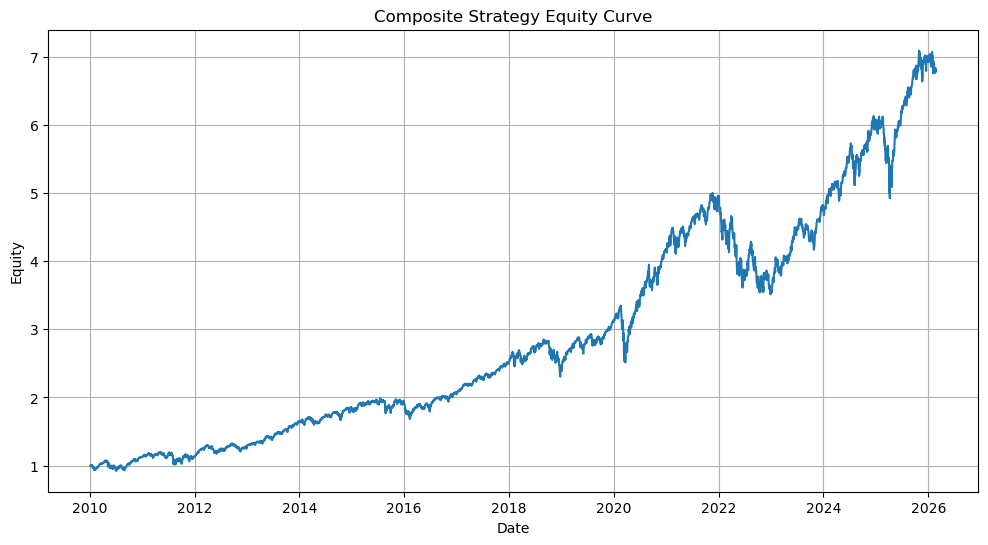

In [76]:
    plt.figure(figsize=(12,6))
    plt.plot(a.index, a["equity"])
    plt.title("Composite Strategy Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

In [66]:
a.tail(50)

,stock_ret,fx_ret,w_stock,w_fx,turnover,cost,strategy_ret,equity
Date,,,,,,,,
2025-12-10,0.003294,0.0,0.80000,0.20000,0.00000,0.000000,0.002635,7.018800
2025-12-11,-0.002549,0.0,0.80000,0.20000,0.00000,0.000000,-0.002039,7.004488
2025-12-12,-0.016898,0.0,0.80000,0.20000,0.00000,0.000000,-0.013518,6.909798
2025-12-15,-0.005939,0.0,0.80000,0.20000,0.00000,0.000000,-0.004751,6.876968
2025-12-16,0.002344,0.0,0.80000,0.20000,0.00000,0.000000,0.001875,6.889864
2025-12-17,-0.018092,0.0,0.80000,0.20000,0.00000,0.000000,-0.014474,6.790141
2025-12-18,0.013794,0.0,0.80000,0.20000,0.00000,0.000000,0.011035,6.865074
2025-12-19,0.013095,0.0,0.80000,0.20000,0.00000,0.000000,0.010476,6.936990
2025-12-22,0.005200,0.0,0.80000,0.20000,0.00000,0.000000,0.004160,6.965851


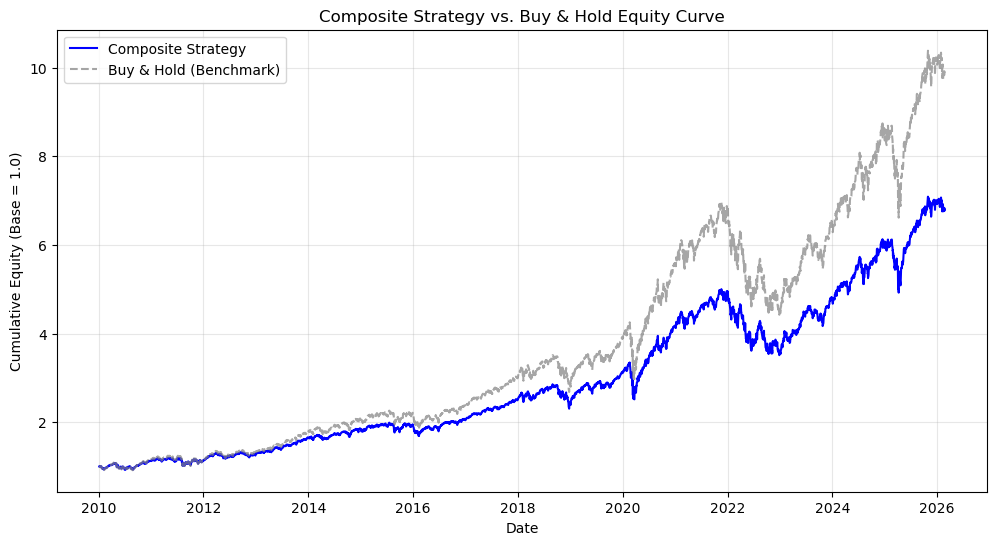

In [78]:
bnh_equity = benchmark_price / benchmark_price.iloc[0]

bnh_equity = bnh_equity.loc[a.index]

plt.figure(figsize=(12, 6))

plt.plot(a.index, a["equity"], label="Composite Strategy", color="blue", linewidth=1.5)

plt.plot(a.index, bnh_equity, label="Buy & Hold (Benchmark)", color="gray", alpha=0.7, linestyle="--")
plt.title("Composite Strategy vs. Buy & Hold Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Equity (Base = 1.0)")
plt.legend() 
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
a["daily_return"] = a["equity"].pct_change().fillna(0)

# 1. Cumulative Return
cum_return = a["equity"].iloc[-1] - 1.0

# 2. Annualized Return
trading_days = len(a)
annual_return = (a["equity"].iloc[-1]) ** (252 / trading_days) - 1.0

# 3. Annualized Volatility
annual_volatility = a["daily_return"].std() * np.sqrt(252)

# 4. Sharpe Ratio

if a["daily_return"].std() != 0:
    sharpe_ratio = (a["daily_return"].mean() / a["daily_return"].std()) * np.sqrt(252)
else:
    sharpe_ratio = 0.0

# 5. Maximum Drawdown
rolling_max = a["equity"].cummax()
drawdown = a["equity"] / rolling_max - 1.0
max_drawdown = drawdown.min()

# 6. Calmar Ratio
if max_drawdown != 0:
    calmar_ratio = annual_return / abs(max_drawdown)
else:
    calmar_ratio = np.inf

print("-" * 30)
print("REPORT")
print("-" * 30)
print(f"testing days: {trading_days} days ( {trading_days/252:.1f} years)")
print(f"Cumulative Return: {cum_return:>8.2%}")
print(f"Annualized Return: {annual_return:>8.2%}")
print(f"Annualized Volatility: {annual_volatility:>8.2%}")
print(f"Maximum Drawdown:   {max_drawdown:>8.2%}")
print(f"Sharpe Ratio:   {sharpe_ratio:>8.2f} ")
print(f"Calmar Ratio:   {calmar_ratio:>8.2f} ")
print("-" * 30)

------------------------------
REPORT
------------------------------
testing days: 4059 days ( 16.1 years)
Cumulative Return:  578.07%
Annualized Return:   12.62%
Annualized Volatility:   16.47%
Maximum Drawdown:    -29.77%
Sharpe Ratio:       0.80 
Calmar Ratio:       0.42 
------------------------------
